Dataset Preview
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2       88             84             33      155  34.7   
1            1      153             77             20      110  18.9   
2            4      164             83             25       72  35.2   
3            0      120             71             37      197  20.2   
4            2      151             77             38      137  28.7   

   DiabetesPedigreeFunction  Age  Outcome  
0                      2.44   45        0  
1                      0.23   45        1  
2                      0.52   46        1  
3                      0.44   44        0  
4                      2.43   58        1  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               50 non-null     int64  

Pregnancies:  2
Glucose Level:  120
Blood Pressure:  70
Skin Thickness:  20
Insulin Level:  79
BMI:  25
Diabetes Pedigree Function:  0.5
Age:  40



Prediction Result : Patient is Diabetic
Prediction Probability: [[0.37184396 0.62815604]]


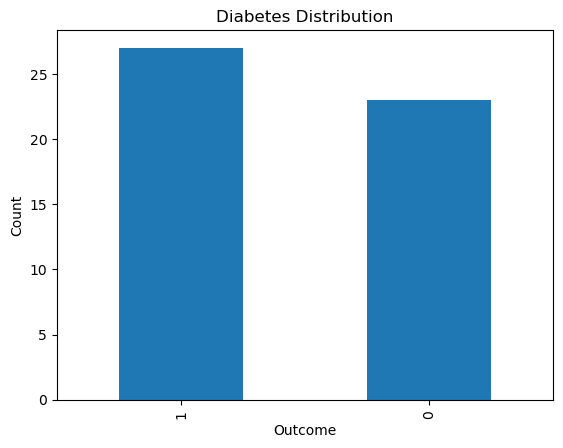

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv("diabetes.csv")

print("Dataset Preview")
print(data.head())

print("\nDataset Information")
print(data.info())

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nEnter Patient Details")

pregnancies = int(input("Pregnancies: "))
glucose = int(input("Glucose Level: "))
blood_pressure = int(input("Blood Pressure: "))
skin_thickness = int(input("Skin Thickness: "))
insulin = int(input("Insulin Level: "))
bmi = float(input("BMI: "))
diabetes_pedigree = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

user_data = pd.DataFrame([[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
]], columns=[
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
])

user_data = scaler.transform(user_data)

prediction = model.predict(user_data)

probability = model.predict_proba(user_data)

if prediction[0] == 1:
    print("\nPrediction Result : Patient is Diabetic")
else:
    print("\nPrediction Result : Patient is Not Diabetic")

print("Prediction Probability:", probability)

data["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()